# Electricity Price Forecasting — Full Evaluation Notebook
**German Day-Ahead Market | Hourly (2020–2025) & Quarter-Hourly (Oct 2025–Feb 2026)**

This notebook follows the thesis structure step by step:
1. Setup & data loading  
2. Exploratory data analysis (EDA)  
3. Train / test split  
4. Naive baseline  
5. ARIMA (properly fitted with ACF/PACF)  
6. LEAR — Lasso Estimated AutoRegressive model  
7. XGBoost  
8. Results comparison table  
9. Pre vs. post reform comparison


## 1 · Setup — Install & Import

In [14]:
# Install required packages (run once)
!pip install statsmodels pmdarima xgboost scikit-learn --quiet


In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (13, 4)
print("All imports OK")


All imports OK


## 2 · Load & Inspect Data

Two datasets:
- **hourly_clean.csv** — Jan 2020 to Sep 2025 (pre-reform, 24 obs/day)  
- **qh_clean.csv** — Oct 2025 to Feb 2026 (post-reform, 96 obs/day)

Adjust the paths below if your files are in a different folder.


In [16]:

HOURLY_PATH = "../data/clean/hourly_clean.csv"
QH_PATH     = "../data/clean/qh_clean.csv"

hourly = pd.read_csv(HOURLY_PATH)
qh     = pd.read_csv(QH_PATH)

hourly["timestamp"] = pd.to_datetime(hourly["timestamp"])
qh["timestamp"]     = pd.to_datetime(qh["timestamp"])

hourly = hourly.set_index("timestamp").sort_index()
qh     = qh.set_index("timestamp").sort_index()

print(f"Hourly : {hourly.index.min().date()} → {hourly.index.max().date()}  | {len(hourly):,} rows")
print(f"QH     : {qh.index.min().date()} → {qh.index.max().date()}  | {len(qh):,} rows")
print()
print(hourly.describe().round(2))


Hourly : 2020-01-01 → 2025-09-30  | 50,399 rows
QH     : 2025-10-01 → 2026-02-17  | 13,156 rows

          price
count  50399.00
mean     104.74
std       99.59
min     -500.00
25%       42.74
50%       84.45
75%      126.01
max      936.28


## 3 · Exploratory Data Analysis

### 3.1 Full price series


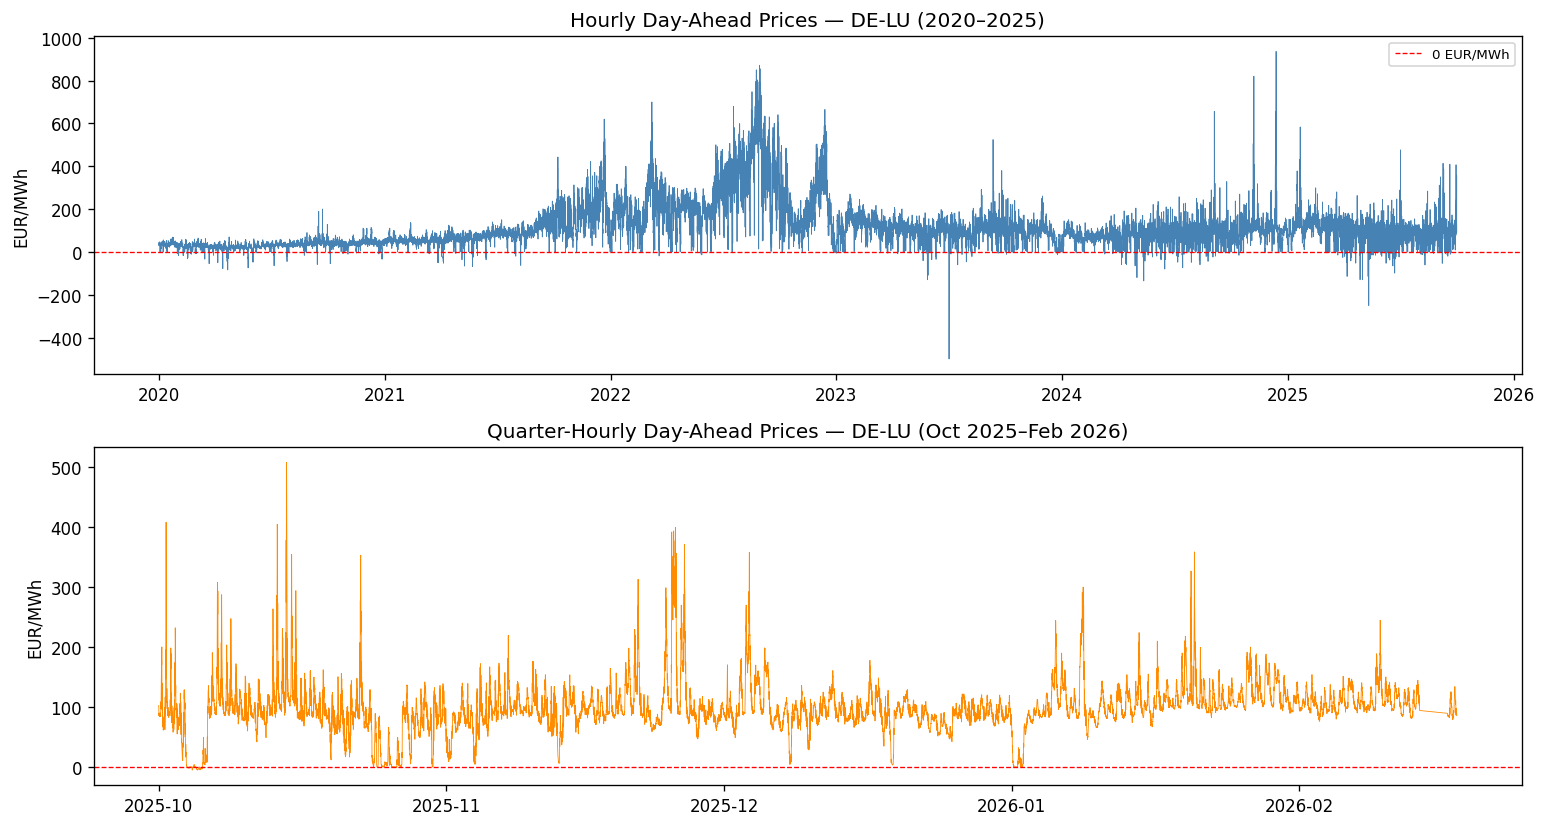

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].plot(hourly.index, hourly["price"], lw=0.5, color="steelblue")
axes[0].set_title("Hourly Day-Ahead Prices — DE-LU (2020–2025)")
axes[0].set_ylabel("EUR/MWh")
axes[0].axhline(0, color="red", lw=0.8, ls="--", label="0 EUR/MWh")
axes[0].legend(fontsize=8)

axes[1].plot(qh.index, qh["price"], lw=0.5, color="darkorange")
axes[1].set_title("Quarter-Hourly Day-Ahead Prices — DE-LU (Oct 2025–Feb 2026)")
axes[1].set_ylabel("EUR/MWh")
axes[1].axhline(0, color="red", lw=0.8, ls="--")

plt.tight_layout()
plt.savefig("../results/eda_full_series.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.2 Seasonality — average price by hour of day

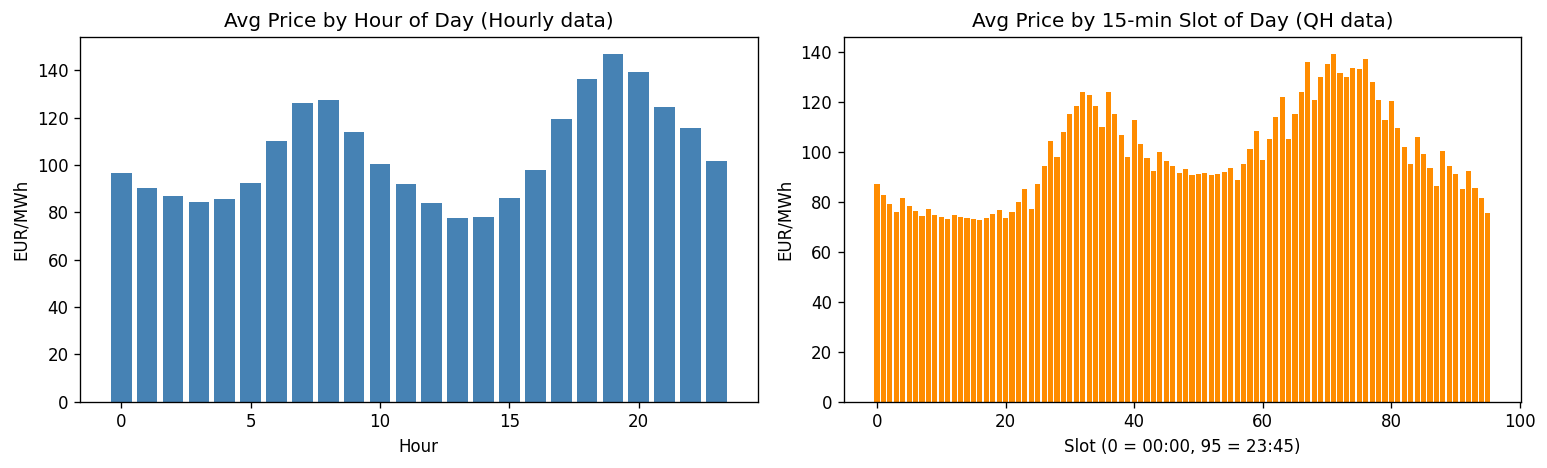

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Hourly: avg by hour-of-day
hourly_hod = hourly.copy()
hourly_hod["hour"] = hourly_hod.index.hour
hod = hourly_hod.groupby("hour")["price"].mean()
axes[0].bar(hod.index, hod.values, color="steelblue")
axes[0].set_title("Avg Price by Hour of Day (Hourly data)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("EUR/MWh")

# QH: avg by 15-min slot of day (0-95)
qh_slot = qh.copy()
qh_slot["slot"] = qh_slot.index.hour * 4 + qh_slot.index.minute // 15
slot_avg = qh_slot.groupby("slot")["price"].mean()
axes[1].bar(slot_avg.index, slot_avg.values, color="darkorange", width=0.8)
axes[1].set_title("Avg Price by 15-min Slot of Day (QH data)")
axes[1].set_xlabel("Slot (0 = 00:00, 95 = 23:45)")
axes[1].set_ylabel("EUR/MWh")

plt.tight_layout()
plt.savefig("../results/eda_seasonality_hod.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.3 Negative prices & spikes

Hourly  — negative prices: 1789 (3.5%)  |  spikes >300: 2641
QH      — negative prices: 209 (1.6%)      |  spikes >300: 70


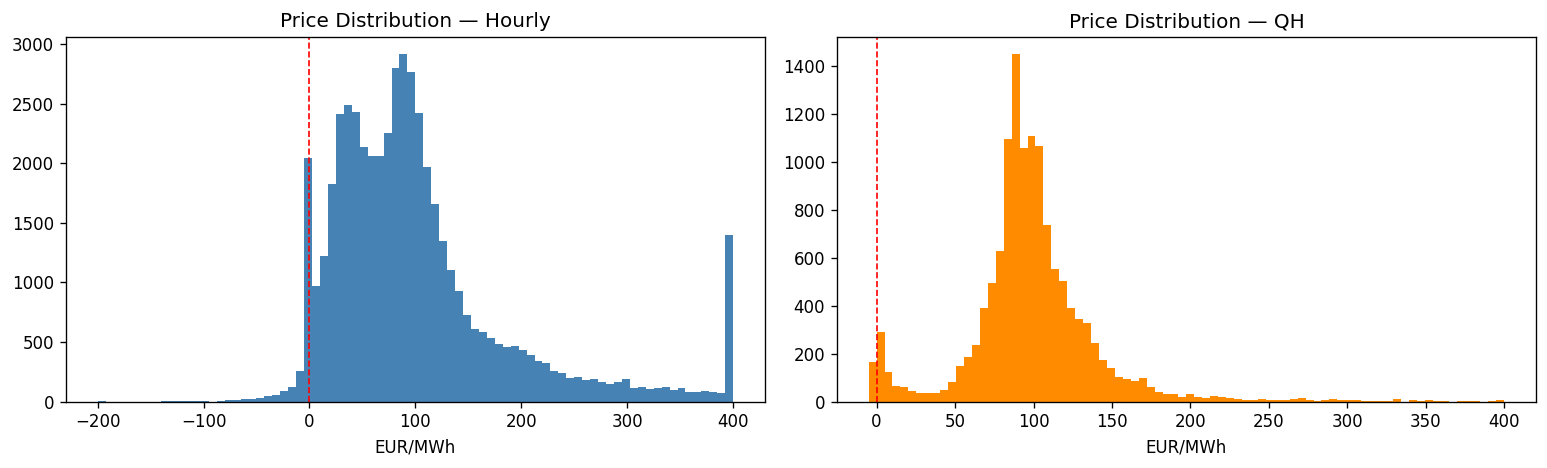

In [19]:
neg_h = (hourly["price"] < 0).sum()
neg_q = (qh["price"] < 0).sum()
spike_h = (hourly["price"] > 300).sum()
spike_q = (qh["price"] > 300).sum()

print(f"Hourly  — negative prices: {neg_h} ({100*neg_h/len(hourly):.1f}%)  |  spikes >300: {spike_h}")
print(f"QH      — negative prices: {neg_q} ({100*neg_q/len(qh):.1f}%)      |  spikes >300: {spike_q}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(hourly["price"].clip(-200, 400), bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(0, color="red", ls="--", lw=1)
axes[0].set_title("Price Distribution — Hourly")
axes[0].set_xlabel("EUR/MWh")

axes[1].hist(qh["price"].clip(-50, 400), bins=80, color="darkorange", edgecolor="none")
axes[1].axvline(0, color="red", ls="--", lw=1)
axes[1].set_title("Price Distribution — QH")
axes[1].set_xlabel("EUR/MWh")

plt.tight_layout()
plt.savefig("../results/eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.4 Stationarity test (ADF)

In [20]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    pval = result[1]
    stat = "STATIONARY ✓" if pval < 0.05 else "NON-STATIONARY ✗"
    print(f"{name:30s}  ADF stat={result[0]:.3f}  p={pval:.4f}  → {stat}")

adf_test(hourly["price"], "Hourly prices (raw)")
adf_test(hourly["price"].diff().dropna(), "Hourly prices (1st diff)")
adf_test(qh["price"], "QH prices (raw)")
adf_test(qh["price"].diff().dropna(), "QH prices (1st diff)")


Hourly prices (raw)             ADF stat=-8.448  p=0.0000  → STATIONARY ✓
Hourly prices (1st diff)        ADF stat=-38.451  p=0.0000  → STATIONARY ✓
QH prices (raw)                 ADF stat=-9.348  p=0.0000  → STATIONARY ✓
QH prices (1st diff)            ADF stat=-24.730  p=0.0000  → STATIONARY ✓


### 3.5 ACF / PACF — needed to choose ARIMA order

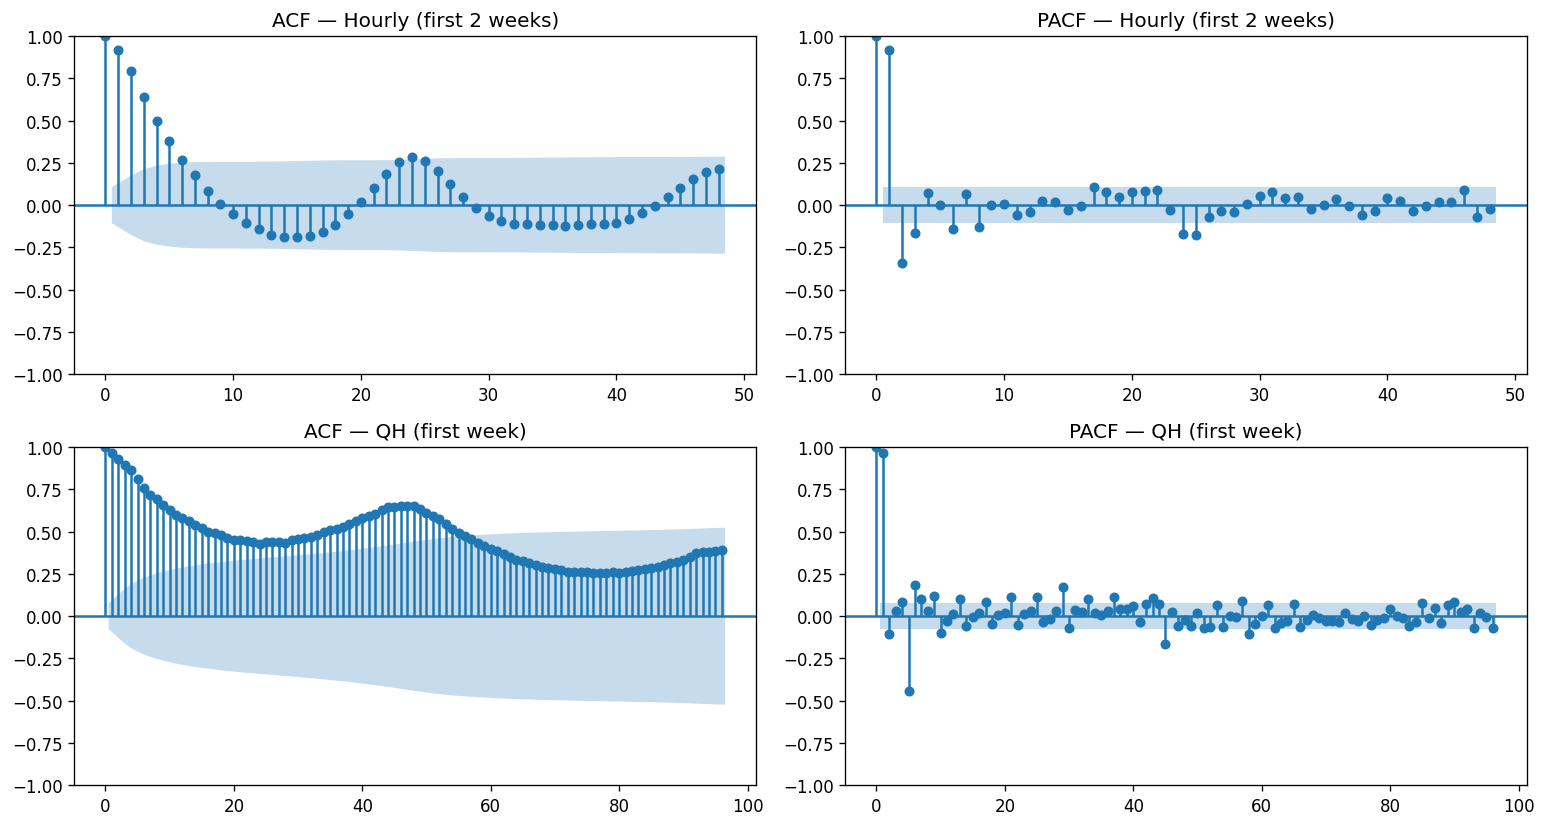

Inspect the plots above to confirm AR and MA lag orders for ARIMA.


In [21]:
# Use a subset for clarity (first 2 weeks of hourly = 336 obs)
sample = hourly["price"].iloc[:336]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

plot_acf(sample, lags=48, ax=axes[0, 0], title="ACF — Hourly (first 2 weeks)")
plot_pacf(sample, lags=48, ax=axes[0, 1], title="PACF — Hourly (first 2 weeks)")

sample_qh = qh["price"].iloc[:4*24*7]  # first week of QH
plot_acf(sample_qh, lags=96, ax=axes[1, 0], title="ACF — QH (first week)")
plot_pacf(sample_qh, lags=96, ax=axes[1, 1], title="PACF — QH (first week)")

plt.tight_layout()
plt.savefig("../results/eda_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Inspect the plots above to confirm AR and MA lag orders for ARIMA.")


## 4 · Train / Test Split

We hold out the **last 2 weeks** of each dataset as the test set.  
Everything before is used for training.

| Dataset | Train | Test |
|---------|-------|------|
| Hourly | Jan 2020 – ~Sep 2025 | Last 2 weeks (336 obs) |
| QH | Oct 2025 – ~Feb 2026 | Last 2 weeks (1344 obs) |


In [22]:
# ── Hourly split ──────────────────────────────────────────────────────────
TEST_HOURS = 24 * 7         # 1 weeks = 168 hourly obs
h_train = hourly.iloc[:-TEST_HOURS]
h_test  = hourly.iloc[-TEST_HOURS:]

# ── QH split ──────────────────────────────────────────────────────────────
TEST_QH = 96 * 7             # 1 weeks = 672 QH obs
q_train = qh.iloc[:-TEST_QH]
q_test  = qh.iloc[-TEST_QH:]

print(f"Hourly  train: {len(h_train):,} | test: {len(h_test):,}")
print(f"QH      train: {len(q_train):,} | test: {len(q_test):,}")


Hourly  train: 50,231 | test: 168
QH      train: 12,484 | test: 672


## 5 · Evaluation Metrics Helper

In [23]:
def evaluate(y_true, y_pred, model_name, dataset_name):
    """Compute MAE, RMSE, MAPE and return as a dict row."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE — skip zeros to avoid division error
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f"[{model_name} | {dataset_name}]  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%")
    return {"Model": model_name, "Dataset": dataset_name,
            "MAE": round(mae, 2), "RMSE": round(rmse, 2), "MAPE%": round(mape, 1)}

results = []   # we will append a dict per model


## 6 · Naive Baseline

The **naive lag-24 / lag-96** forecast: predict tomorrow's price as the price
from the same hour/slot exactly one day ago.  
This is the floor — every other model must beat it.


In [24]:
# ── Hourly naive: lag 24 ──────────────────────────────────────────────────
lag = 24
naive_h = h_train["price"].iloc[-lag:].values   # last 24 hours of train
# Repeat for each day in test (14 days)
naive_h_pred = np.tile(naive_h, TEST_HOURS // lag)

results.append(evaluate(h_test["price"].values, naive_h_pred,
                         "Naive (lag-24)", "Hourly"))

# ── QH naive: lag 96 ──────────────────────────────────────────────────────
lag_q = 96
naive_q = q_train["price"].iloc[-lag_q:].values
naive_q_pred = np.tile(naive_q, TEST_QH // lag_q)

results.append(evaluate(q_test["price"].values, naive_q_pred,
                         "Naive (lag-96)", "QH"))


[Naive (lag-24) | Hourly]  MAE=23.25  RMSE=40.34  MAPE=42.4%
[Naive (lag-96) | QH]  MAE=12.17  RMSE=18.59  MAPE=10.1%


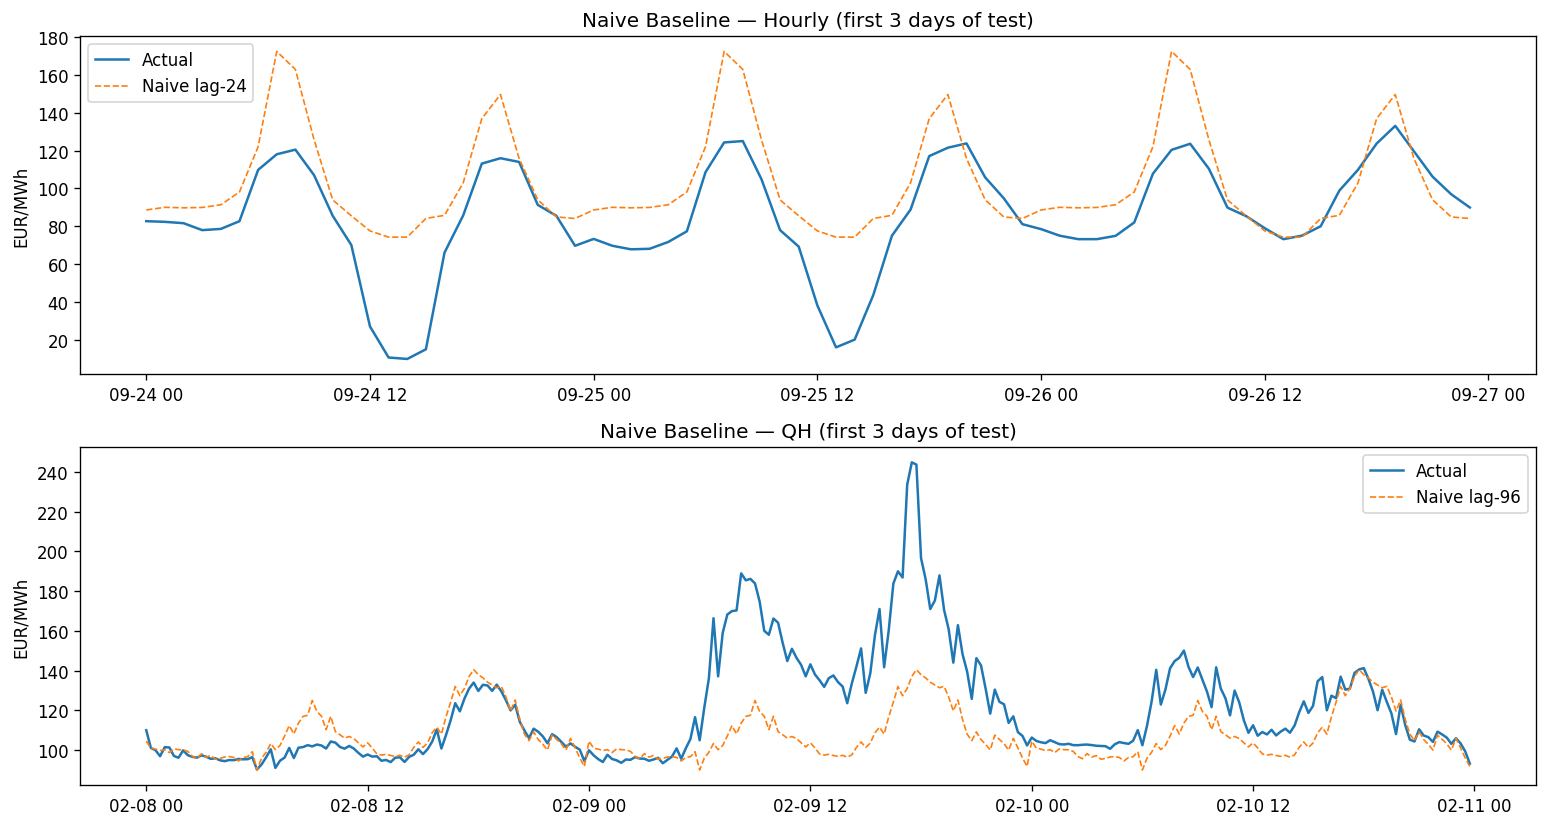

In [25]:
# Plot naive vs actual (first 3 days of test)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].plot(h_test.index[:72], h_test["price"].values[:72], label="Actual", lw=1.5)
axes[0].plot(h_test.index[:72], naive_h_pred[:72], label="Naive lag-24", lw=1, ls="--")
axes[0].set_title("Naive Baseline — Hourly (first 3 days of test)")
axes[0].set_ylabel("EUR/MWh"); axes[0].legend()

axes[1].plot(q_test.index[:288], q_test["price"].values[:288], label="Actual", lw=1.5)
axes[1].plot(q_test.index[:288], naive_q_pred[:288], label="Naive lag-96", lw=1, ls="--")
axes[1].set_title("Naive Baseline — QH (first 3 days of test)")
axes[1].set_ylabel("EUR/MWh"); axes[1].legend()

plt.tight_layout()
plt.savefig("../results/model_naive.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · ARIMA

We choose the order based on the ACF/PACF plots above.  
A common starting point for electricity prices is **ARIMA(2, 1, 2)** — adjust
`ORDER_H` and `ORDER_Q` below after inspecting your own plots.

> **Note:** ARIMA is fitted on a rolling window here, which is slow but honest.
> For speed we use a one-step rolling forecast over the test period.


In [27]:
ORDER_H = (2, 1, 2)   # ← change after looking at ACF/PACF
ORDER_Q = (2, 1, 2)   # ← same for QH

def arima_rolling_forecast(train_series, test_series, order, label):
    """Walk-forward one-step ARIMA forecast over the test set."""
    history = list(train_series)
    preds = []
    n = len(test_series)
    print(f"Running ARIMA{order} rolling forecast for {label} ({n} steps)...")
    for i, actual in enumerate(test_series):
        model = ARIMA(history, order=order)
        fit   = model.fit()
        yhat  = fit.forecast(steps=1)[0]
        preds.append(yhat)
        history.append(actual)   # update with truth (walk-forward)
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{n} done")
    print("  Done.")
    return np.array(preds)

arima_h_pred = arima_rolling_forecast(
    h_train["price"], h_test["price"].values, ORDER_H, "Hourly")
results.append(evaluate(h_test["price"].values, arima_h_pred,
                         f"ARIMA{ORDER_H}", "Hourly"))


Running ARIMA(2, 1, 2) rolling forecast for Hourly (168 steps)...
  100/168 done
  Done.
[ARIMA(2, 1, 2) | Hourly]  MAE=15.35  RMSE=36.33  MAPE=15.3%


In [28]:
arima_q_pred = arima_rolling_forecast(
    q_train["price"], q_test["price"].values, ORDER_Q, "QH")
results.append(evaluate(q_test["price"].values, arima_q_pred,
                         f"ARIMA{ORDER_Q}", "QH"))


Running ARIMA(2, 1, 2) rolling forecast for QH (672 steps)...
  100/672 done
  200/672 done
  300/672 done
  400/672 done
  500/672 done
  600/672 done
  Done.
[ARIMA(2, 1, 2) | QH]  MAE=4.25  RMSE=6.62  MAPE=3.5%


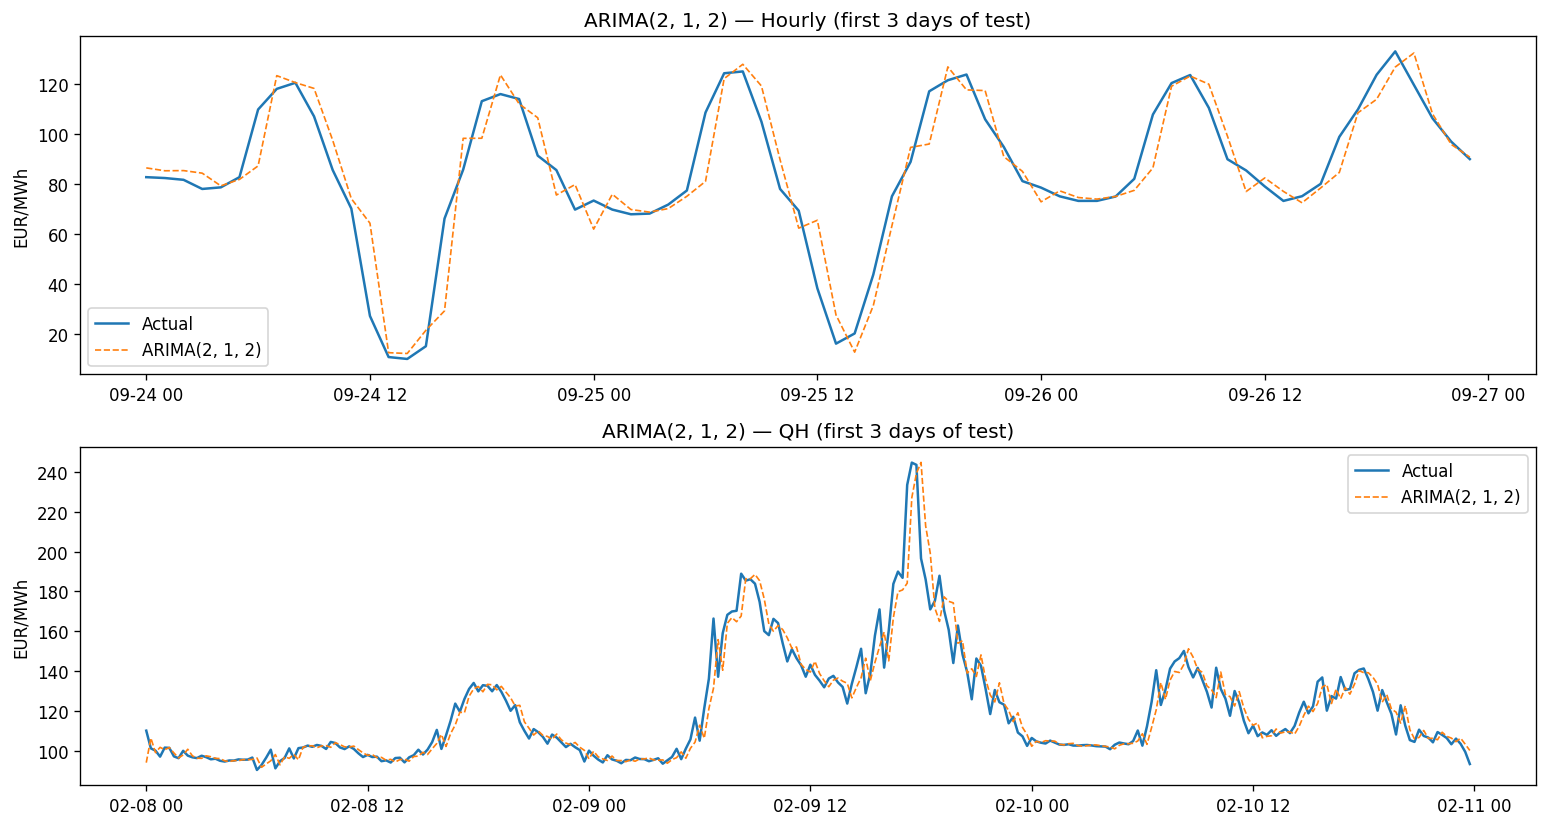

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(h_test.index[:72], h_test["price"].values[:72], label="Actual", lw=1.5)
axes[0].plot(h_test.index[:72], arima_h_pred[:72], label=f"ARIMA{ORDER_H}", lw=1, ls="--")
axes[0].set_title(f"ARIMA{ORDER_H} — Hourly (first 3 days of test)")
axes[0].set_ylabel("EUR/MWh"); axes[0].legend()

axes[1].plot(q_test.index[:288], q_test["price"].values[:288], label="Actual", lw=1.5)
axes[1].plot(q_test.index[:288], arima_q_pred[:288], label=f"ARIMA{ORDER_Q}", lw=1, ls="--")
axes[1].set_title(f"ARIMA{ORDER_Q} — QH (first 3 days of test)")
axes[1].set_ylabel("EUR/MWh"); axes[1].legend()

plt.tight_layout()
plt.savefig("../results/model_arima.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · LEAR — Lasso Estimated AutoRegressive Model

LEAR is an ARX model with many lag features (past prices + calendar dummies),
regularised with LASSO (L1) to select which lags actually matter.

Feature set per observation:
- **Price lags**: lag-1, lag-2, lag-24 (or lag-96), lag-48 (or lag-192),
  and the full previous day's 24 (or 96) prices
- **Calendar**: hour-of-day, day-of-week, is_weekend

One model is fitted **per period** (separate model for each of the 24 hours,
or each of the 96 slots) — this is the per-period approach described in the
thesis (Section 2.2.1).


In [30]:
def build_lear_features(series, period_len):
    """
    Build an ARX feature matrix for LEAR.
    period_len = 24 (hourly) or 96 (QH)
    Returns X (DataFrame) and y (Series), aligned.
    """
    df = pd.DataFrame({"price": series})
    df["hour"]       = df.index.hour
    df["dow"]        = df.index.dayofweek
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    df["slot"]       = df.index.hour * 4 + df.index.minute // 15

    # Lag features
    for lag in [1, 2, period_len, 2 * period_len]:
        df[f"lag_{lag}"] = df["price"].shift(lag)

    # Previous full day (all period_len prices)
    for s in range(period_len):
        df[f"prev_day_{s}"] = df["price"].shift(period_len + s)

    df = df.dropna()
    feature_cols = [c for c in df.columns if c != "price"]
    return df[feature_cols], df["price"]


def fit_lear(train_df, test_df, period_len, label):
    """
    Fit one Lasso model per period slot, predict test set.
    """
    X_train, y_train = build_lear_features(train_df["price"], period_len)
    X_test,  y_test  = build_lear_features(
        pd.concat([train_df["price"].iloc[-(2*period_len):], test_df["price"]]),
        period_len)
    # X_test rows correspond only to test indices after dropna
    X_test = X_test.iloc[-len(test_df):]
    y_test = y_test.iloc[-len(test_df):]

    period_col = "slot" if period_len == 96 else "hour"
    preds = np.zeros(len(y_test))
    scaler = StandardScaler()

    for p in range(period_len):
        mask_tr = (X_train[period_col] == p)
        mask_te = (X_test[period_col]  == p)
        if mask_tr.sum() < 10 or mask_te.sum() == 0:
            continue
        Xtr = X_train[mask_tr].drop(columns=[period_col, "dow"])
        ytr = y_train[mask_tr]
        Xte = X_test[mask_te].drop(columns=[period_col, "dow"])

        Xtr_s = scaler.fit_transform(Xtr)
        Xte_s = scaler.transform(Xte)

        model = Lasso(alpha=0.1, max_iter=5000)
        model.fit(Xtr_s, ytr)
        idx = np.where(mask_te.values)[0]
        preds[idx] = model.predict(Xte_s)

    print(f"LEAR fitted for {label}")
    return preds, y_test.values

lear_h_pred, lear_h_true = fit_lear(h_train, h_test, 24,  "Hourly")
results.append(evaluate(lear_h_true, lear_h_pred, "LEAR", "Hourly"))


LEAR fitted for Hourly
[LEAR | Hourly]  MAE=10.73  RMSE=23.99  MAPE=11.9%


In [31]:
lear_q_pred, lear_q_true = fit_lear(q_train, q_test, 96, "QH")
results.append(evaluate(lear_q_true, lear_q_pred, "LEAR", "QH"))


LEAR fitted for QH
[LEAR | QH]  MAE=2.89  RMSE=4.52  MAPE=2.4%


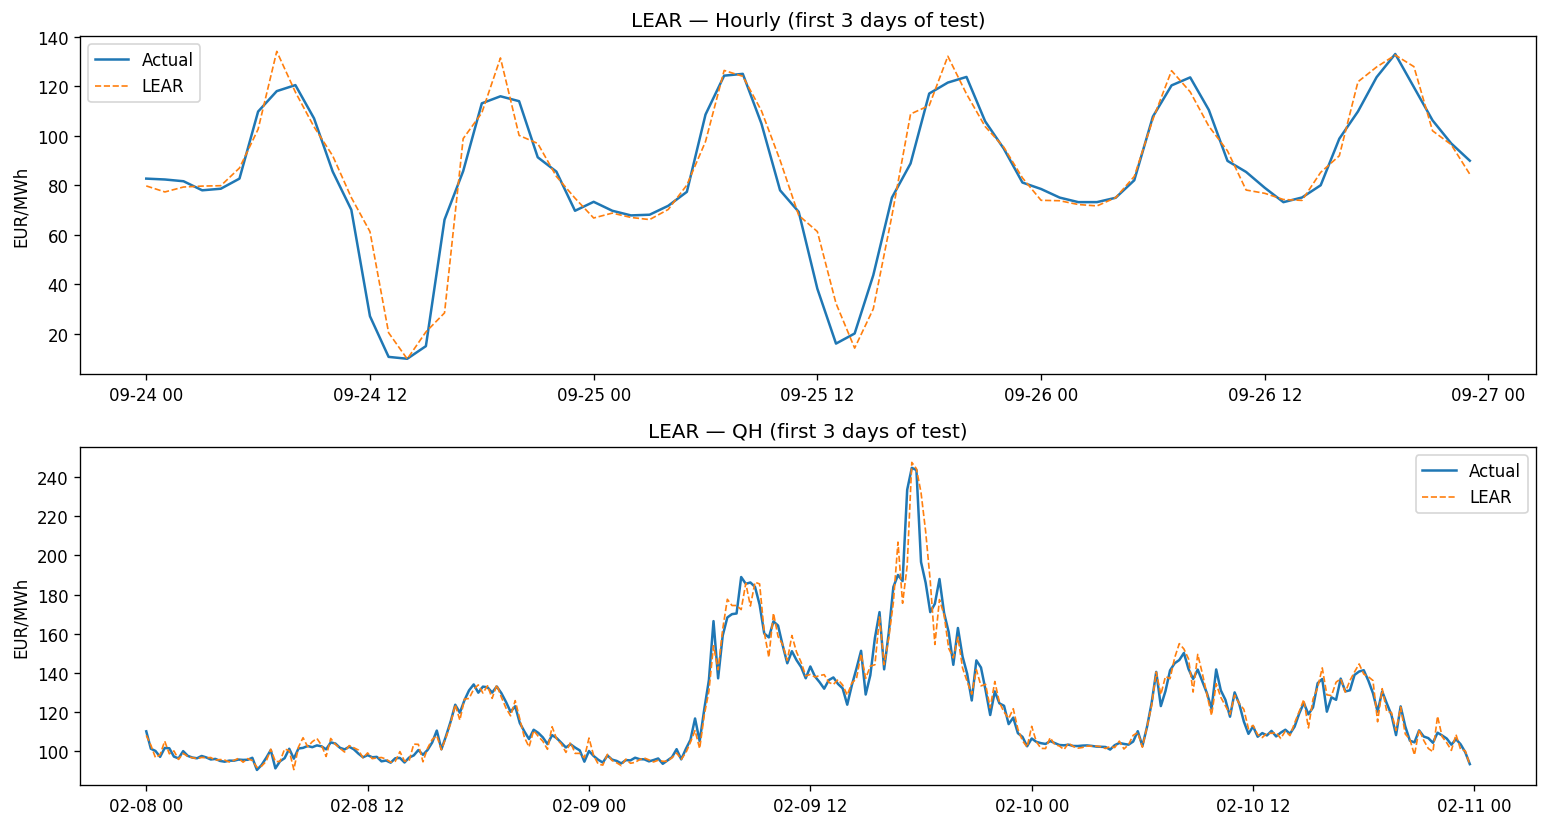

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(h_test.index[:72], lear_h_true[:72], label="Actual", lw=1.5)
axes[0].plot(h_test.index[:72], lear_h_pred[:72], label="LEAR", lw=1, ls="--")
axes[0].set_title("LEAR — Hourly (first 3 days of test)")
axes[0].set_ylabel("EUR/MWh"); axes[0].legend()

axes[1].plot(q_test.index[:288], lear_q_true[:288], label="Actual", lw=1.5)
axes[1].plot(q_test.index[:288], lear_q_pred[:288], label="LEAR", lw=1, ls="--")
axes[1].set_title("LEAR — QH (first 3 days of test)")
axes[1].set_ylabel("EUR/MWh"); axes[1].legend()

plt.tight_layout()
plt.savefig("../results/model_lear.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 · XGBoost

XGBoost is a gradient-boosted tree model that captures **nonlinear** price
dynamics that ARIMA and LEAR cannot.  
We reuse the same feature matrix as LEAR but train a single global model
(not per-period), letting XGBoost learn interactions between slots, lags,
and calendar features automatically.


In [33]:
def fit_xgboost(train_df, test_df, period_len, label):
    X_train, y_train = build_lear_features(train_df["price"], period_len)
    X_test,  y_test  = build_lear_features(
        pd.concat([train_df["price"].iloc[-(2*period_len):], test_df["price"]]),
        period_len)
    X_test = X_test.iloc[-len(test_df):]
    y_test = y_test.iloc[-len(test_df):]

    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    preds = model.predict(X_test)
    print(f"XGBoost fitted for {label}")
    return preds, y_test.values, model

xgb_h_pred, xgb_h_true, xgb_h_model = fit_xgboost(h_train, h_test, 24, "Hourly")
results.append(evaluate(xgb_h_true, xgb_h_pred, "XGBoost", "Hourly"))


XGBoost fitted for Hourly
[XGBoost | Hourly]  MAE=9.23  RMSE=20.33  MAPE=10.0%


In [34]:
xgb_q_pred, xgb_q_true, xgb_q_model = fit_xgboost(q_train, q_test, 96, "QH")
results.append(evaluate(xgb_q_true, xgb_q_pred, "XGBoost", "QH"))


XGBoost fitted for QH
[XGBoost | QH]  MAE=3.12  RMSE=4.81  MAPE=2.6%


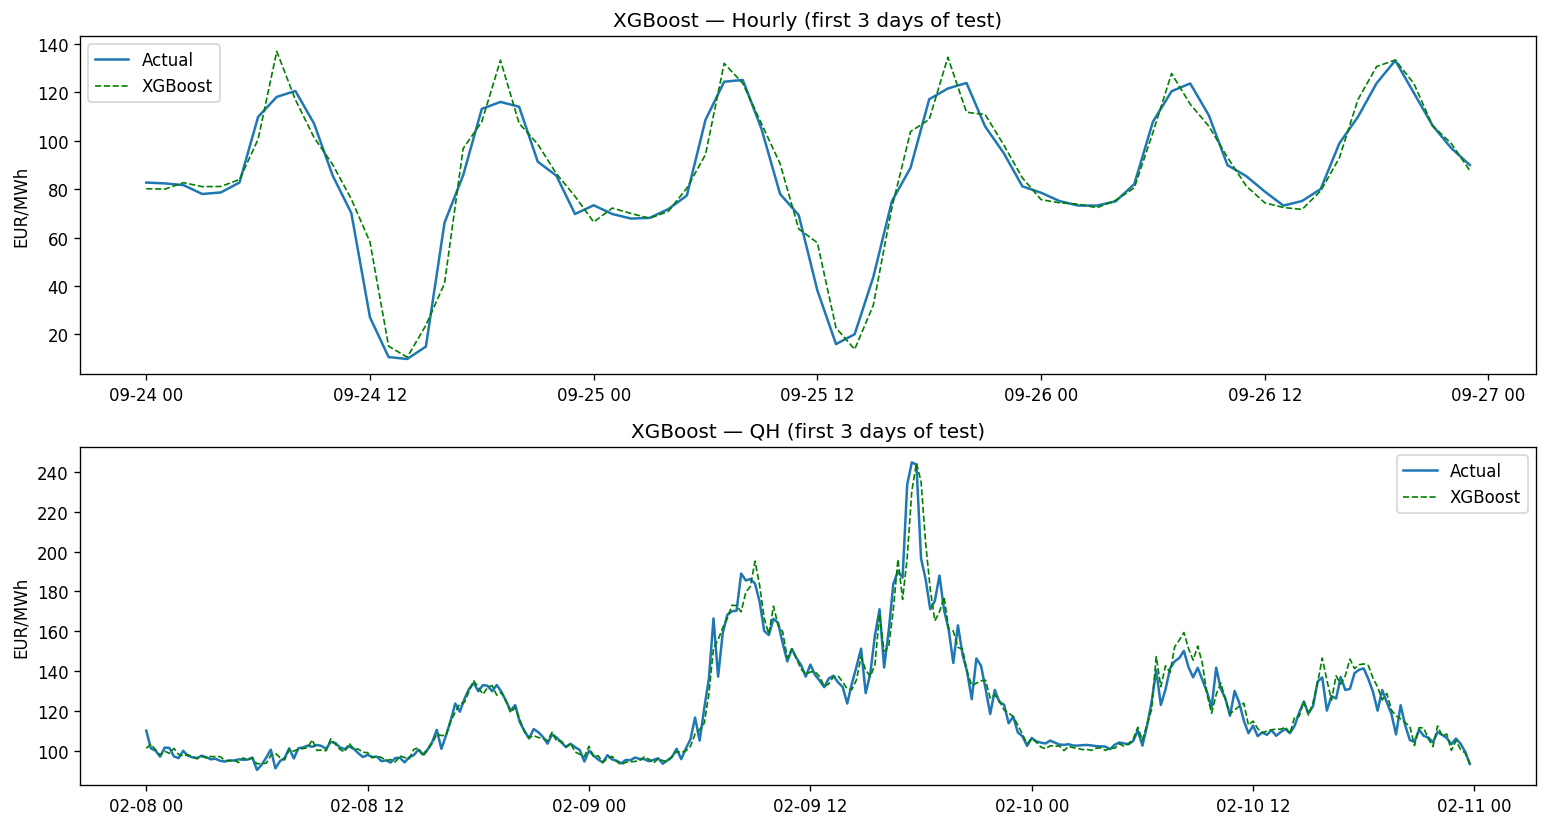

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(h_test.index[:72], xgb_h_true[:72], label="Actual", lw=1.5)
axes[0].plot(h_test.index[:72], xgb_h_pred[:72], label="XGBoost", lw=1, ls="--", color="green")
axes[0].set_title("XGBoost — Hourly (first 3 days of test)")
axes[0].set_ylabel("EUR/MWh"); axes[0].legend()

axes[1].plot(q_test.index[:288], xgb_q_true[:288], label="Actual", lw=1.5)
axes[1].plot(q_test.index[:288], xgb_q_pred[:288], label="XGBoost", lw=1, ls="--", color="green")
axes[1].set_title("XGBoost — QH (first 3 days of test)")
axes[1].set_ylabel("EUR/MWh"); axes[1].legend()

plt.tight_layout()
plt.savefig("../results/model_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()


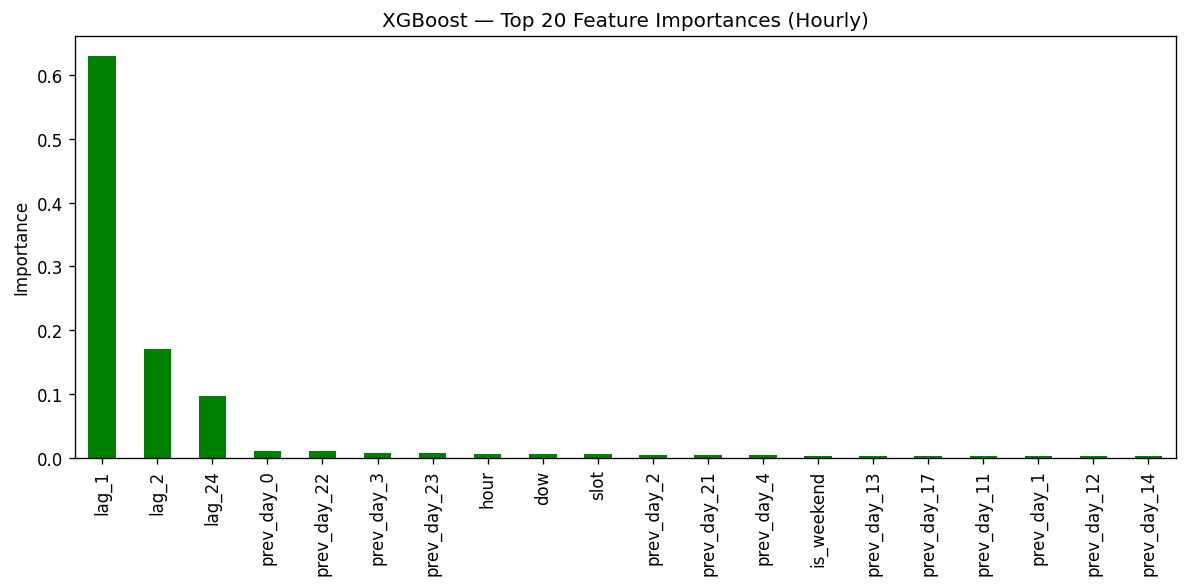

In [36]:
# Feature importance for XGBoost (Hourly)
feat_imp = pd.Series(xgb_h_model.feature_importances_,
                     index=xgb_h_model.get_booster().feature_names)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind="bar", color="green")
plt.title("XGBoost — Top 20 Feature Importances (Hourly)")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("../results/model_xgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 10 · Results Comparison

All models evaluated on the **held-out 2-week test set**.  
Lower MAE / RMSE / MAPE% is better.


In [37]:
results_df = pd.DataFrame(results)

print("=" * 65)
print("MODEL COMPARISON — 2-week test set")
print("=" * 65)
print(results_df.to_string(index=False))
print()

# Pivot for easy reading
for dataset in ["Hourly", "QH"]:
    subset = results_df[results_df["Dataset"] == dataset].set_index("Model")
    print(f"── {dataset} ──")
    print(subset[["MAE", "RMSE", "MAPE%"]].to_string())
    print()


MODEL COMPARISON — 2-week test set
         Model Dataset   MAE  RMSE  MAPE%
Naive (lag-24)  Hourly 23.25 40.34   42.4
Naive (lag-96)      QH 12.17 18.59   10.1
ARIMA(2, 1, 2)  Hourly 15.35 36.33   15.3
ARIMA(2, 1, 2)  Hourly 15.35 36.33   15.3
ARIMA(2, 1, 2)      QH  4.25  6.62    3.5
          LEAR  Hourly 10.73 23.99   11.9
          LEAR      QH  2.89  4.52    2.4
       XGBoost  Hourly  9.23 20.33   10.0
       XGBoost      QH  3.12  4.81    2.6

── Hourly ──
                  MAE   RMSE  MAPE%
Model                              
Naive (lag-24)  23.25  40.34   42.4
ARIMA(2, 1, 2)  15.35  36.33   15.3
ARIMA(2, 1, 2)  15.35  36.33   15.3
LEAR            10.73  23.99   11.9
XGBoost          9.23  20.33   10.0

── QH ──
                  MAE   RMSE  MAPE%
Model                              
Naive (lag-96)  12.17  18.59   10.1
ARIMA(2, 1, 2)   4.25   6.62    3.5
LEAR             2.89   4.52    2.4
XGBoost          3.12   4.81    2.6



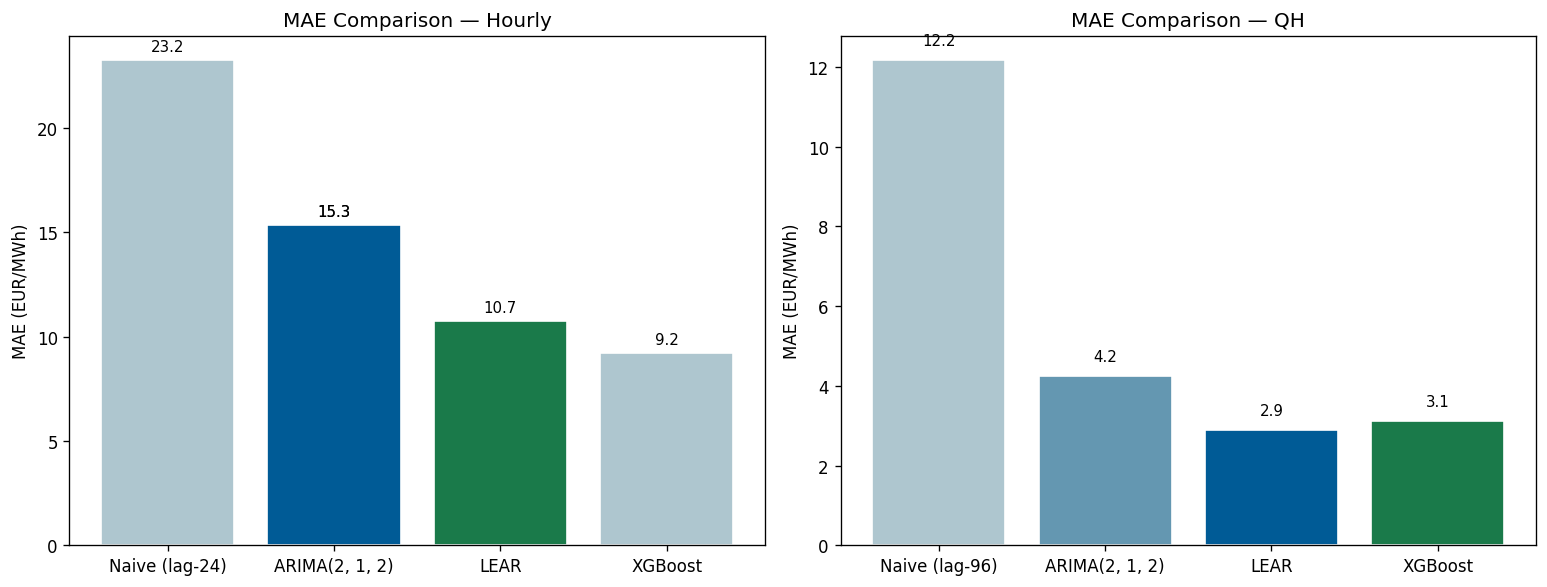

In [38]:
# Bar chart of MAE per model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, dataset in zip(axes, ["Hourly", "QH"]):
    subset = results_df[results_df["Dataset"] == dataset]
    colors = ["#aec6cf", "#6497b1", "#005b96", "#1a7a4a"][:len(subset)]
    bars = ax.bar(subset["Model"], subset["MAE"], color=colors, edgecolor="white")
    ax.set_title(f"MAE Comparison — {dataset}")
    ax.set_ylabel("MAE (EUR/MWh)")
    for bar, val in zip(bars, subset["MAE"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{val:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../results/results_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 11 · Pre vs. Post Reform Comparison

This section visualises the structural change introduced by the 2025 reform
(Section 2.1.2 of the thesis): the same calendar window shown in hourly
and quarter-hourly resolution side by side.


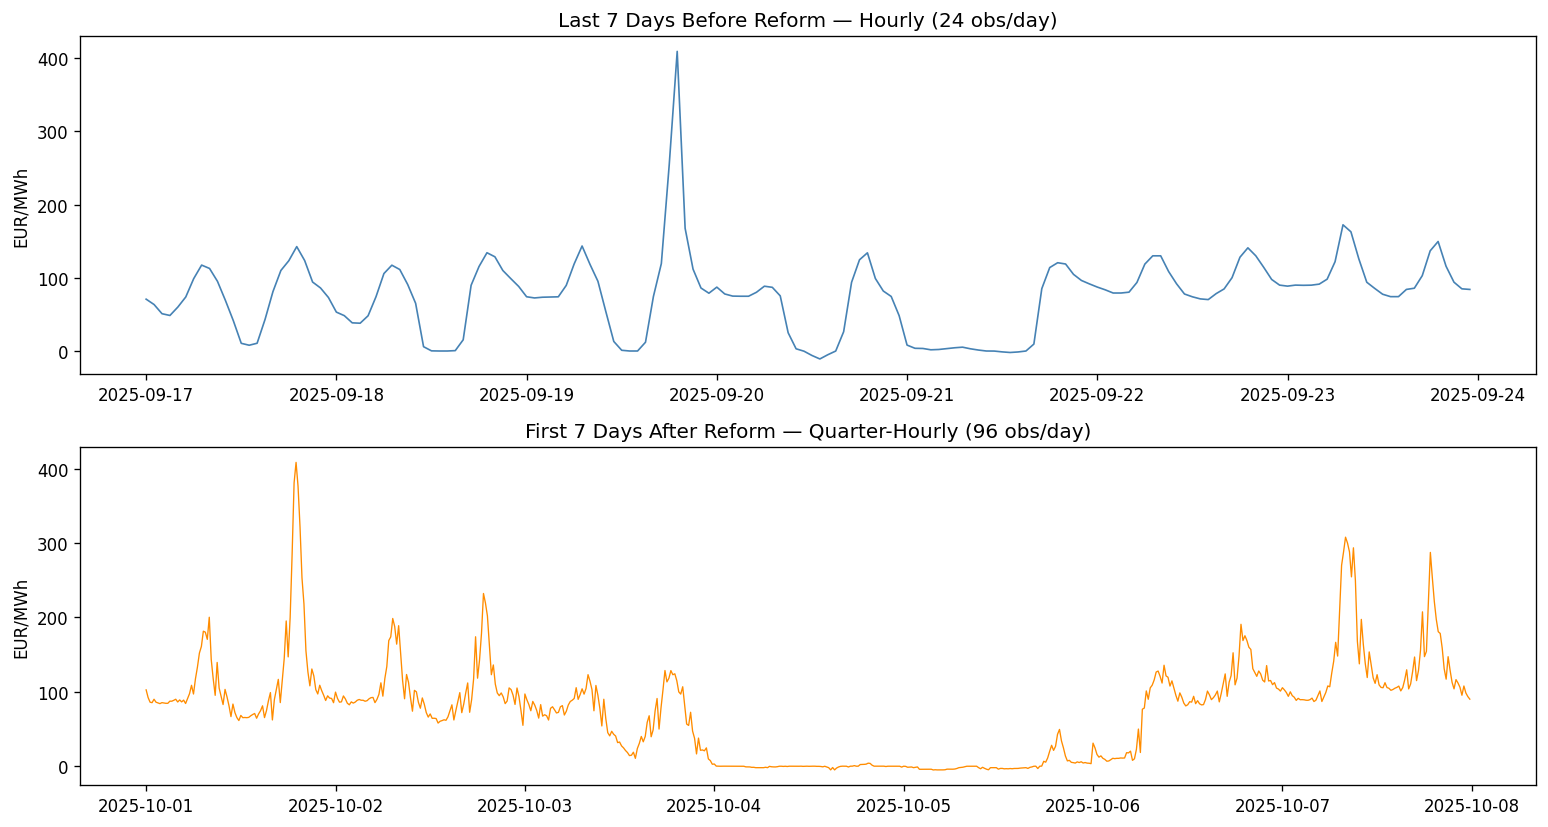

In [39]:
# Pick an overlapping window if any exists, otherwise use equivalent calendar dates
# Hourly ends Sep 2025 / QH starts Oct 2025 — we use the final week of hourly
# and the first week of QH as "comparable" windows

h_last_week = h_train.iloc[-7*24:]   # last 7 days of hourly
q_first_week = q_train.iloc[:7*96]   # first 7 days of QH

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

axes[0].plot(h_last_week.index, h_last_week["price"], color="steelblue", lw=1)
axes[0].set_title("Last 7 Days Before Reform — Hourly (24 obs/day)")
axes[0].set_ylabel("EUR/MWh")

axes[1].plot(q_first_week.index, q_first_week["price"], color="darkorange", lw=0.8)
axes[1].set_title("First 7 Days After Reform — Quarter-Hourly (96 obs/day)")
axes[1].set_ylabel("EUR/MWh")

plt.tight_layout()
plt.savefig("../results/reform_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


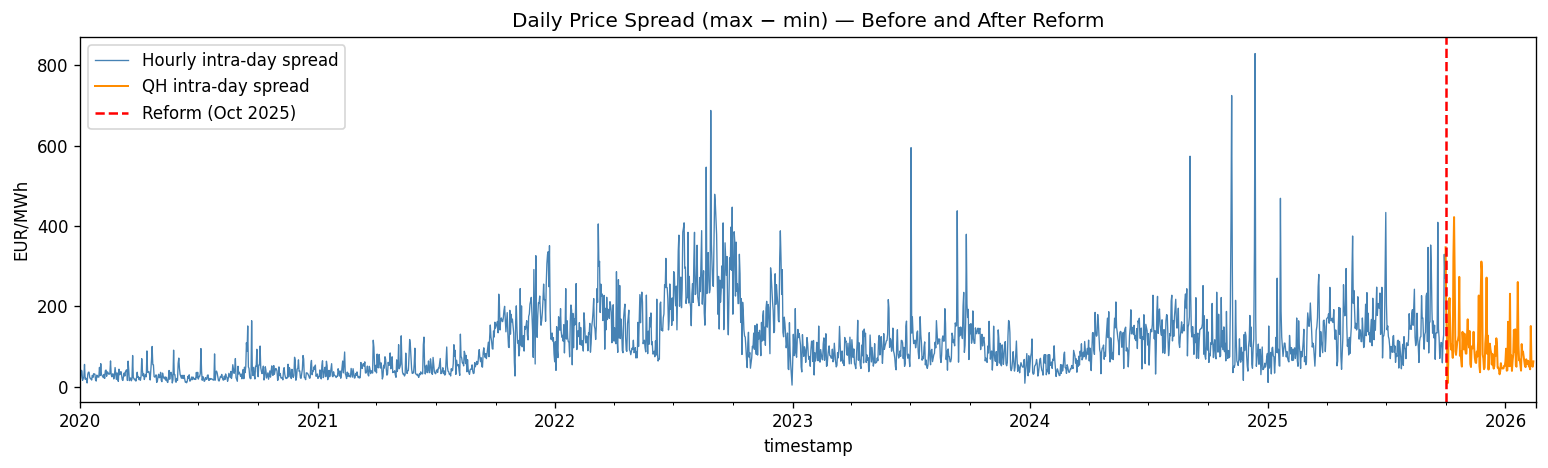


Avg daily spread (Hourly pre-reform) : 106.4 EUR/MWh
Avg daily spread (QH post-reform)    : 100.3 EUR/MWh


In [40]:
# Intra-day spread: max - min per day
h_spread = hourly.resample("D")["price"].apply(lambda x: x.max() - x.min())
q_spread = qh.resample("D")["price"].apply(lambda x: x.max() - x.min())

fig, ax = plt.subplots(figsize=(13, 4))
h_spread.plot(ax=ax, label="Hourly intra-day spread", color="steelblue", lw=0.8)
q_spread.plot(ax=ax, label="QH intra-day spread", color="darkorange", lw=1.2)
ax.axvline(pd.Timestamp("2025-10-01"), color="red", ls="--", lw=1.5, label="Reform (Oct 2025)")
ax.set_title("Daily Price Spread (max − min) — Before and After Reform")
ax.set_ylabel("EUR/MWh")
ax.legend()
plt.tight_layout()
plt.savefig("../results/reform_spread.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAvg daily spread (Hourly pre-reform) : {h_spread.mean():.1f} EUR/MWh")
print(f"Avg daily spread (QH post-reform)    : {q_spread.mean():.1f} EUR/MWh")


## 12 · Summary & Next Steps

**What this notebook produced:**
- EDA: full series, seasonality, distributions, stationarity tests, ACF/PACF
- Train/test split with a clean 2-week held-out test set
- Four models benchmarked on MAE, RMSE, MAPE:
  - Naive baseline (lag-24 / lag-96)
  - ARIMA (walk-forward rolling forecast)
  - LEAR (per-period Lasso ARX)
  - XGBoost (global gradient-boosted tree)
- Pre vs. post reform visualisation

**Suggested next steps:**
1. Tune ARIMA order using AIC/BIC after inspecting the ACF/PACF plots
2. Add exogenous features to LEAR/XGBoost (load forecast, wind/solar, gas prices)
3. Implement a neural network (LSTM or Temporal Fusion Transformer) for Section 2.2.3
4. Run Diebold-Mariano test for statistical significance of forecast differences
5. Write Sections 2.2.2, 2.2.3, and 2.3 of the thesis based on these results
